In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
from geopy.distance import geodesic
from path_config import PathConfig
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import math
paths = PathConfig()

In [5]:
buildings = gpd.read_file(paths.build_path)
vegetation = gpd.read_file(paths.vege_path)
water = gpd.read_file(paths.waters_path)
roads = gpd.read_file(paths.roads_path)
border = gpd.read_file(paths.border_path)
kabinets = pd.read_csv((paths._processed_saha_olcum_dir / "Kabinets.csv"))
kabinets = kabinets.loc[:, ~kabinets.columns.str.contains('^Unnamed')]

layers = [buildings, vegetation, water, roads, border]
for layer in layers:
    if layer.crs != "EPSG:32635":
        layer = layer.to_crs(epsg=32635)

utm_crs = "EPSG:32635"

buildings, vegetation, water, roads, border = layers

stations_gdf = gpd.GeoDataFrame(
    kabinets,
    geometry=gpd.points_from_xy(np.array(kabinets["Longitude"]), np.array(kabinets["Latitude"])),
    crs="EPSG:4326"
).to_crs(utm_crs)

grid_spacing = 5
border = border.to_crs(utm_crs)
minx, miny, maxx, maxy = border.total_bounds
x_coords = np.arange(minx, maxx, grid_spacing)
y_coords = np.arange(miny, maxy, grid_spacing)

grid_points = [Point(x, y) for x in x_coords for y in y_coords]
grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs=utm_crs).to_crs(utm_crs)

border_polygon = Polygon(border.geometry.iloc[0])
grid_gdf = grid_gdf[grid_gdf.geometry.within(border_polygon)]

In [6]:
dl_data = pd.read_excel(paths.dl_path, sheet_name='Series Formatted Data')
ul_data = pd.read_excel(paths.ul_path, sheet_name='Series Formatted Data')

dl_data = dl_data.drop(["Message","Technology_Mode"],axis=1)
dl_data = dl_data.loc[:, ~dl_data.columns.str.contains('^Unnamed')]

ul_data = ul_data.drop(["Message","Technology_Mode"],axis=1)
ul_data = ul_data.loc[:, ~ul_data.columns.str.contains('^Unnamed')]

dl_data_group_by_location = pd.read_csv(paths._processed_saha_olcum_dir / "dl_data_group_by_location.csv")

In [7]:
dl_data_group_by_location = dl_data_group_by_location[[
                    "x",
                    "y",
                    "Longitude",
                    "Latitude",
                    "NR_UE_RSRP_0",
                    "NR_UE_Nbr_RSRP_0",
                    "NR_UE_Nbr_RSRP_1",
                    "NR_UE_Nbr_RSRP_2",
                    "NR_UE_Nbr_RSRP_3",
                    "NR_UE_Nbr_RSRP_4",
                    "NR_UE_PCI_0",
                    "NR_UE_Nbr_PCI_0",
                    "NR_UE_Nbr_PCI_1",
                    "NR_UE_Nbr_PCI_2",
                    "NR_UE_Nbr_PCI_3",
                    "NR_UE_Nbr_PCI_4"
                    ]]

pci_cols = [col for col in dl_data_group_by_location.columns if "PCI" in col]
rsrp_cols = [col for col in dl_data_group_by_location.columns if "RSRP" in col]

dl_data_group_by_location = dl_data_group_by_location.dropna(how="all", subset=pci_cols)

In [8]:
grid_locations = np.column_stack((grid_gdf.geometry.x, grid_gdf.geometry.y))

In [9]:
def calculate_bearing(lat1, lon1, lat2, lon2):
    
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlon = lon2_rad - lon1_rad
    
    y = math.sin(dlon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(dlon)
    
    bearing_rad = math.atan2(y, x)
    
    bearing_deg = (math.degrees(bearing_rad) + 360) % 360
    
    return bearing_deg

In [10]:
def latitude_to_meter(data, col=None):
    if col:
        latitude = data[col]*111320
    else:
        latitude = data*111320
    return latitude

def longitude_to_meter(data, cols=None):
    # cols[0] Latitude, cols[1] Longitude
    if cols:
        longitude = np.cos(np.radians(data[cols[0]]))*111320*(data[cols[1]])
    else:
        longitude = np.cos(np.radians(data[0]))*111320*(data[1])
    return longitude

In [11]:
def create_signal_data(signal_column, pci_column, data, col_names, fill_na_value=-200):
    col_names = np.append(col_names, ['Longitude','Latitude'])
    
    signal_data_list = []
    for idx, row in data[pci_column].iterrows():
        temp_dict = {}
        for t,i in enumerate(row):
            if not np.isnan(i):
                temp_dict[str(int(i))] = data[signal_column[t]][idx]
                temp_dict['Longitude'], temp_dict['Latitude'] = data['Longitude'][idx], data['Latitude'][idx]
        signal_data_list.append(temp_dict)
    signal_data = pd.DataFrame(signal_data_list)[col_names].fillna(fill_na_value)

    lon, lat = longitude_to_meter(signal_data, cols=["Latitude","Longitude"]), latitude_to_meter(signal_data, col=["Latitude"])
    signal_data["Latitude"], signal_data["Longitude"] = lat, lon
    
    return signal_data

signal_data = create_signal_data(
    signal_column = rsrp_cols, 
    pci_column = pci_cols, 
    data = dl_data_group_by_location, 
    col_names = stations_gdf["PCI"].values
    )

signal_data

,30,40,59,48,68,76,3,13,23,Longitude,Latitude
0,-200.00,-125.15,-200.0,-200.0,-124.30,-124.5,-200.0,-200.0,-200.0,2.433790e+06,4.575884e+06
1,-123.30,-123.05,-200.0,-200.0,-125.00,-123.8,-200.0,-200.0,-200.0,2.433788e+06,4.575891e+06
2,-124.15,-122.50,-200.0,-200.0,-125.35,-125.4,-200.0,-124.9,-200.0,2.433786e+06,4.575897e+06
3,-200.00,-124.75,-200.0,-200.0,-123.65,-121.2,-200.0,-200.0,-200.0,2.433784e+06,4.575901e+06
4,-200.00,-124.85,-200.0,-200.0,-122.60,-121.5,-200.0,-200.0,-200.0,2.433784e+06,4.575903e+06
...,...,...,...,...,...,...,...,...,...,...,...
1120,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435251e+06,4.575211e+06
1121,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435272e+06,4.575211e+06
1122,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435305e+06,4.575222e+06
1123,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435312e+06,4.575223e+06


In [29]:
def create_features(stations, data):
    locations = np.array(data[["Latitude","Longitude"]])
    bs_locations = np.column_stack((stations.Latitude,stations.Longitude))
    bs_data = stations[['Azimuth','Vertical_Beamwidth','Height']]

    # j baz istasyonunu, i lokasyonu temsil ediyor
    def create_features_j(bs_loc,locations):
        
        features_j = []
        for loc in locations: 
            distance = geodesic(loc, bs_loc).meters
            features_ij= [
                latitude_to_meter(loc[0]),                    
                longitude_to_meter(loc),                  
                latitude_to_meter(bs_loc[0]),                            
                longitude_to_meter(bs_loc),                 
                distance,
                np.log(max(distance, 1)),
                calculate_bearing(loc[0], loc[1], bs_loc[0], bs_loc[1]),
                float(bs_data["Azimuth"].iloc[0]),
                float(bs_data["Vertical_Beamwidth"].iloc[0]),
                float(bs_data["Height"].iloc[0])
                # eklenebilecek özellikler:
                # su var ya da yok, bina varsa kat yüksekliği, yeşillik var ya da yok gibi.
                ]
            features_j.append(features_ij)

        return np.array(features_j)
    
    return np.stack([create_features_j(bs_loc,locations) for bs_loc in bs_locations])

features = create_features(stations_gdf, dl_data_group_by_location)
print(features.shape)

grid_data = np.column_stack((grid_gdf.to_crs("EPSG:4326").geometry.y, grid_gdf.to_crs("EPSG:4326").geometry.x))
grid_data = pd.DataFrame(grid_data, columns=["Latitude", "Longitude"])
grid_data

pred_features = create_features(stations_gdf, grid_data)

print(pred_features.shape)

(9, 1125, 10)
(9, 68463, 10)


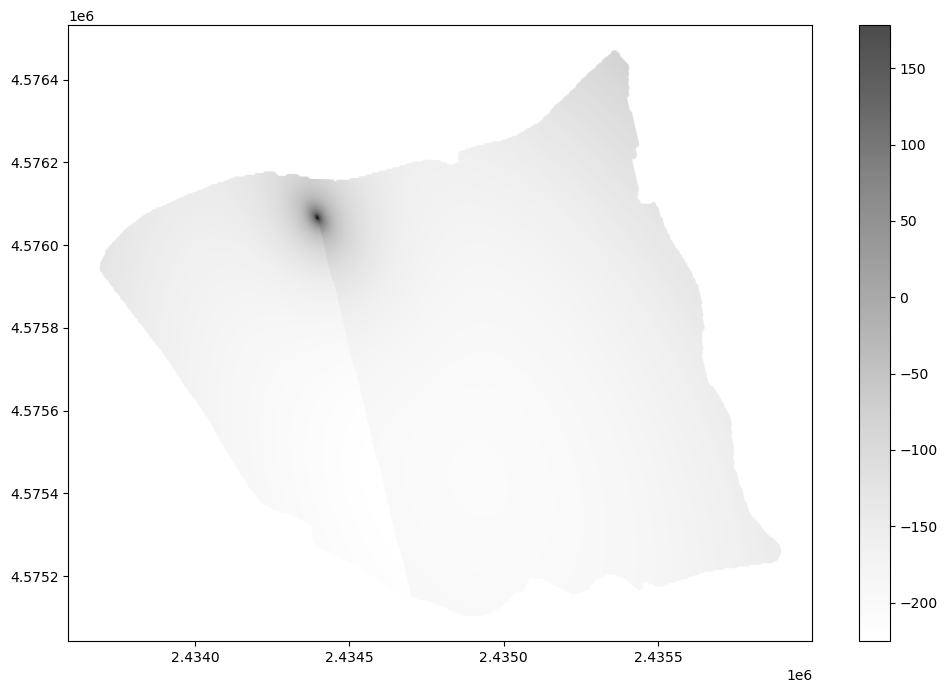

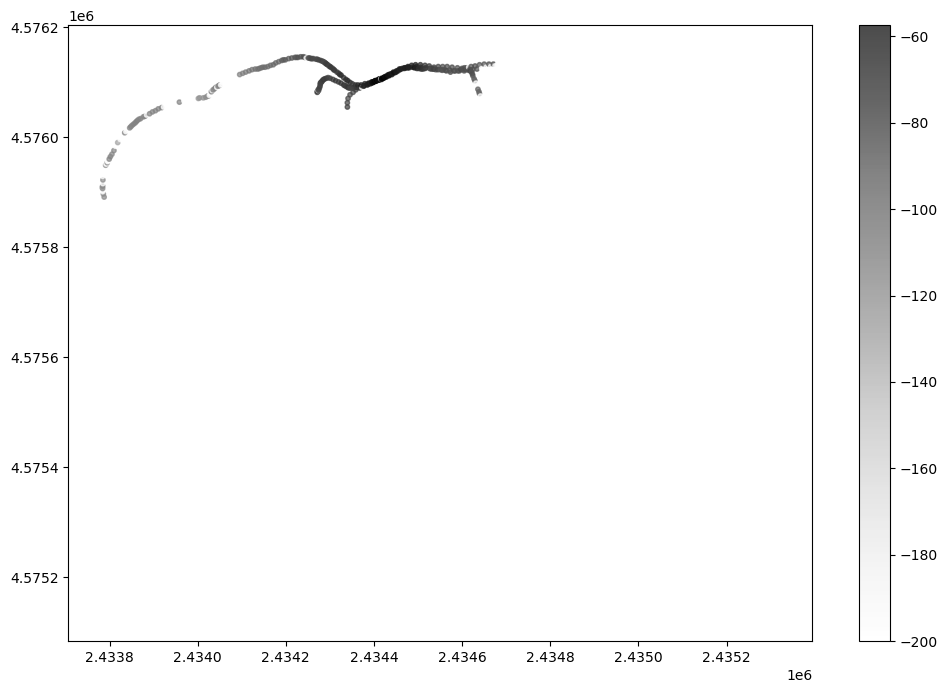

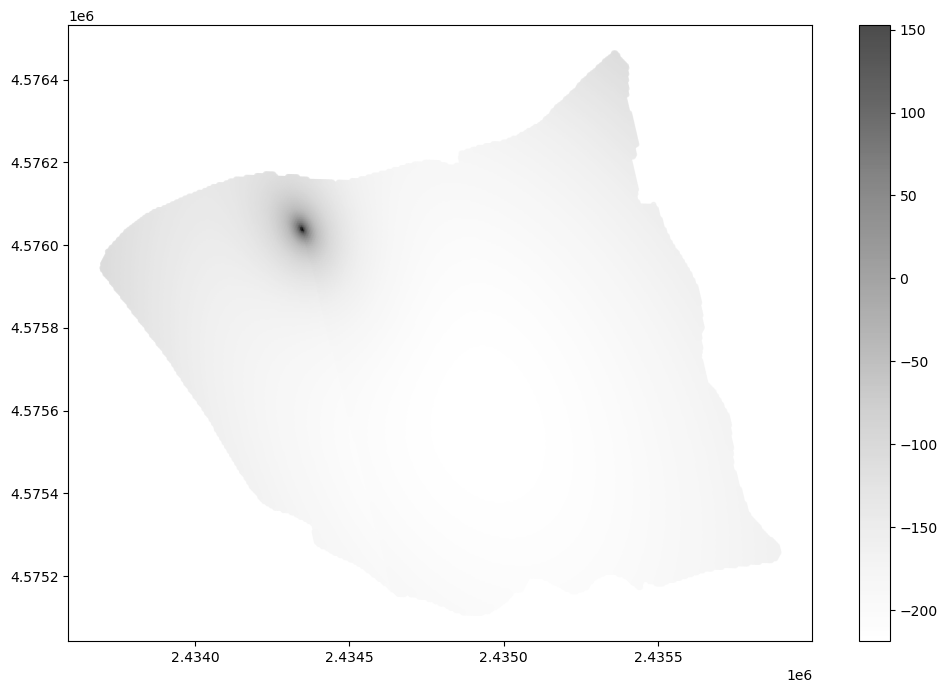

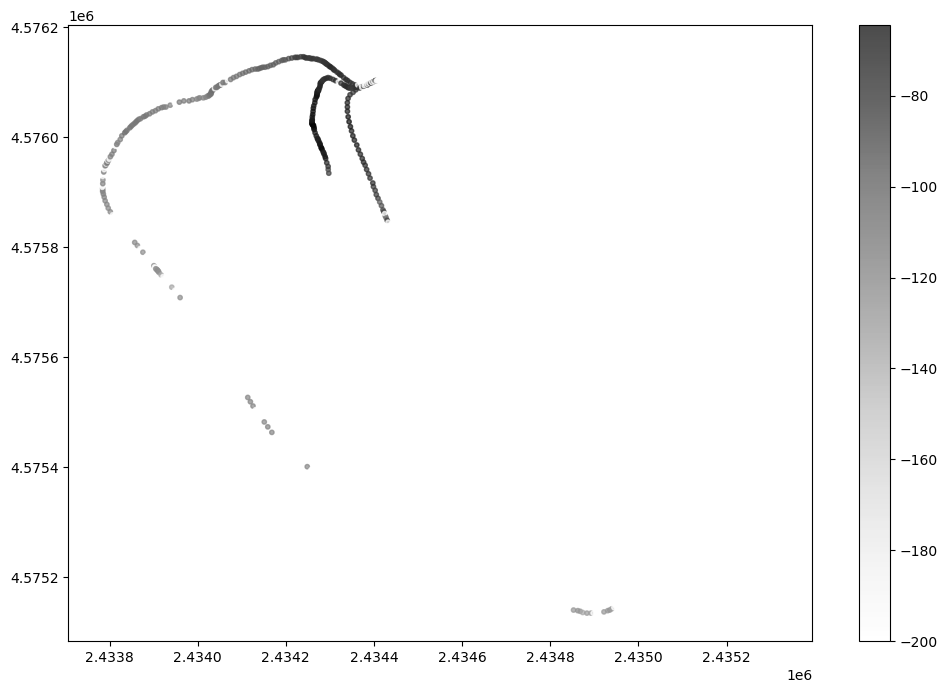

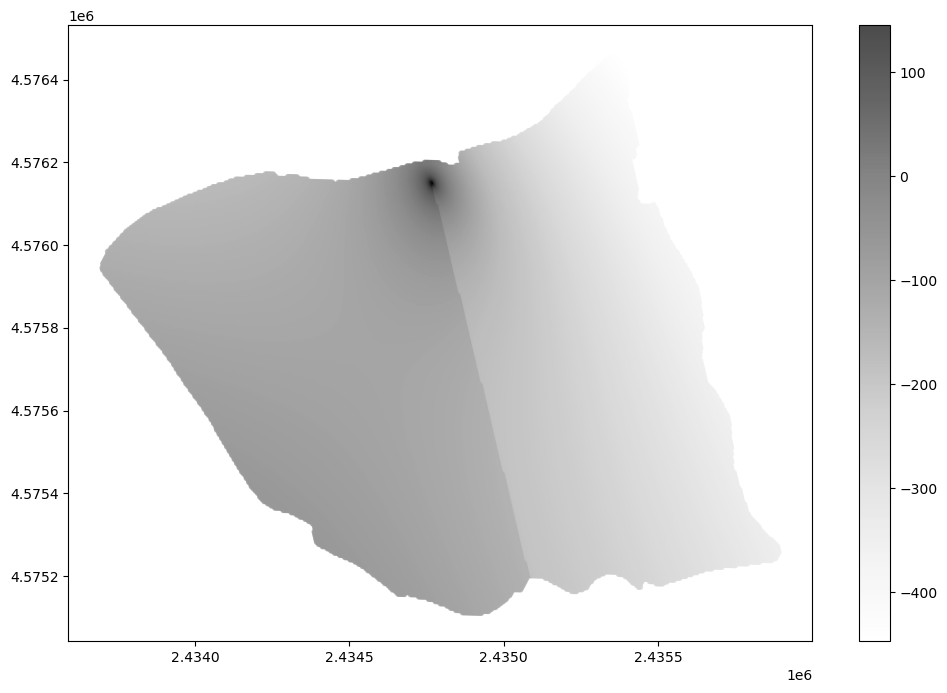

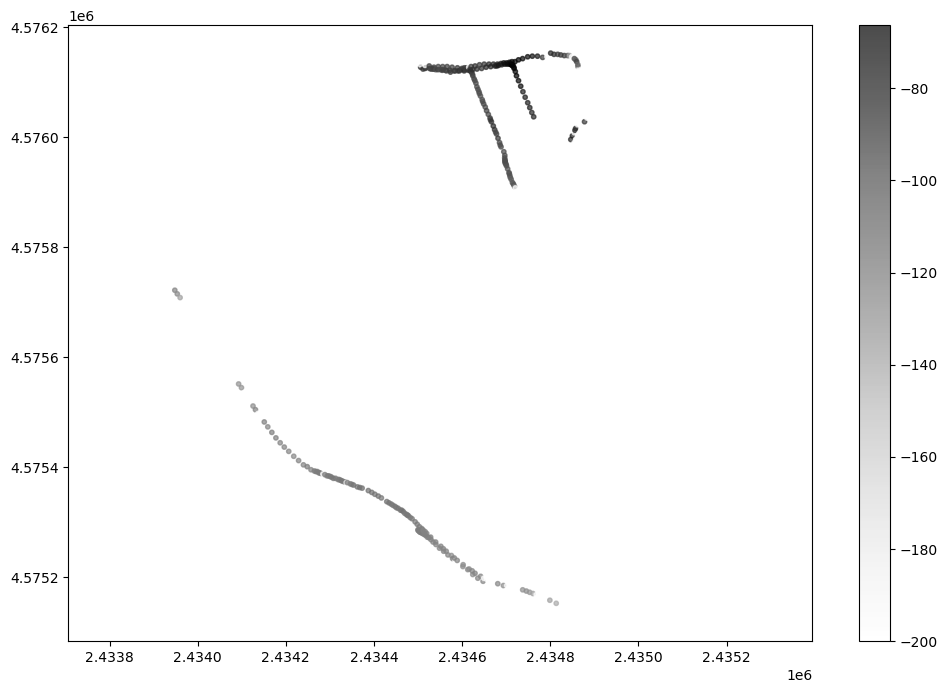

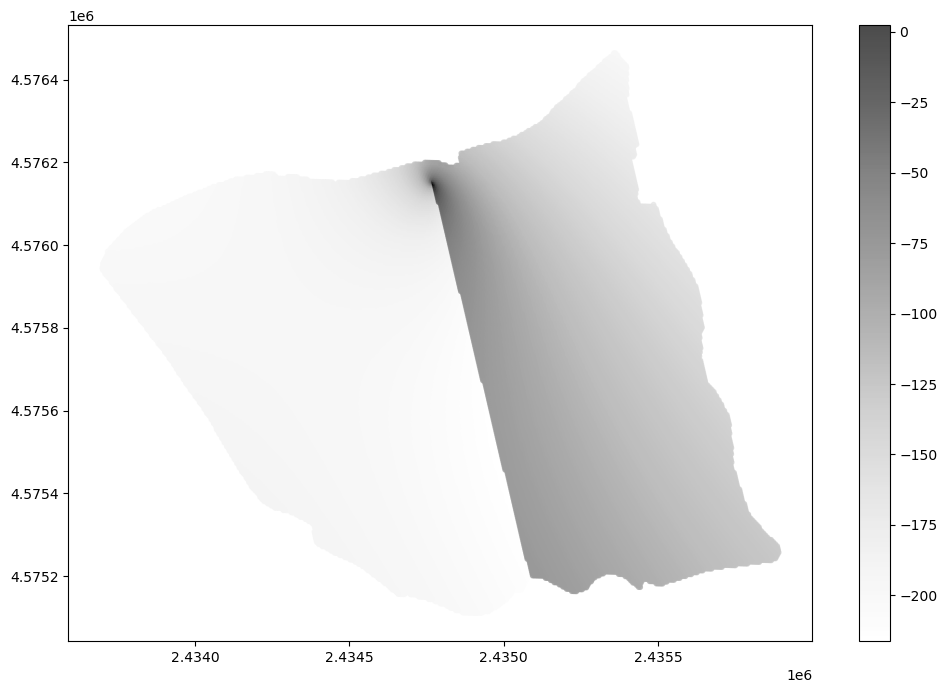

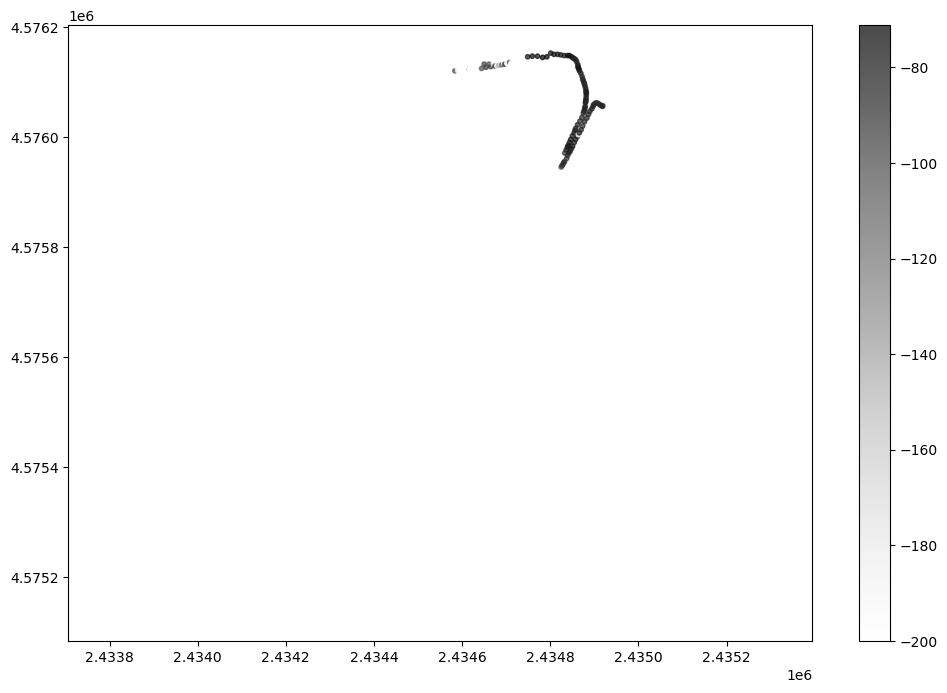

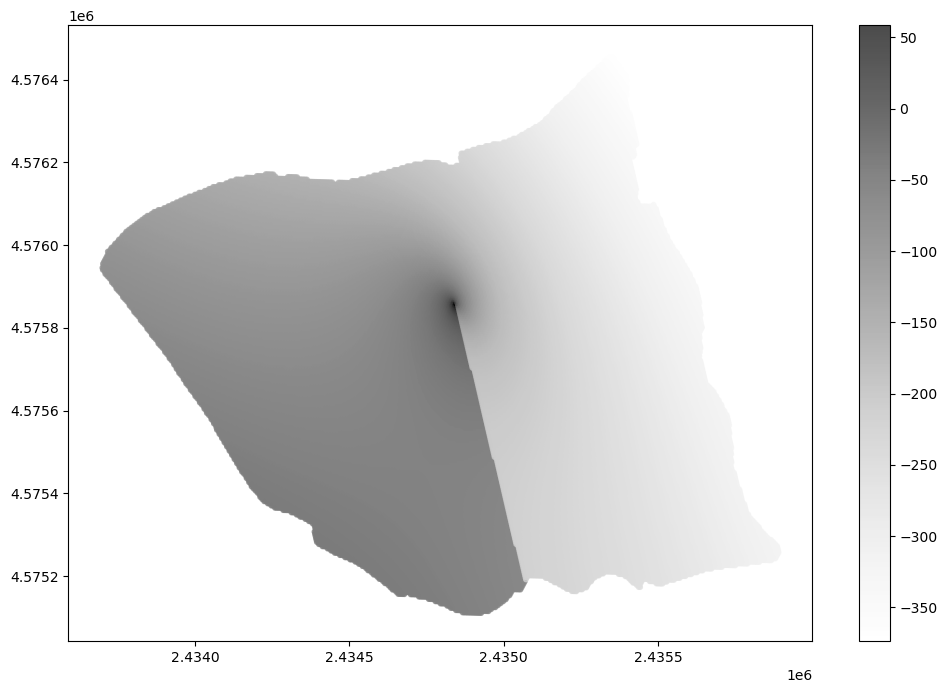

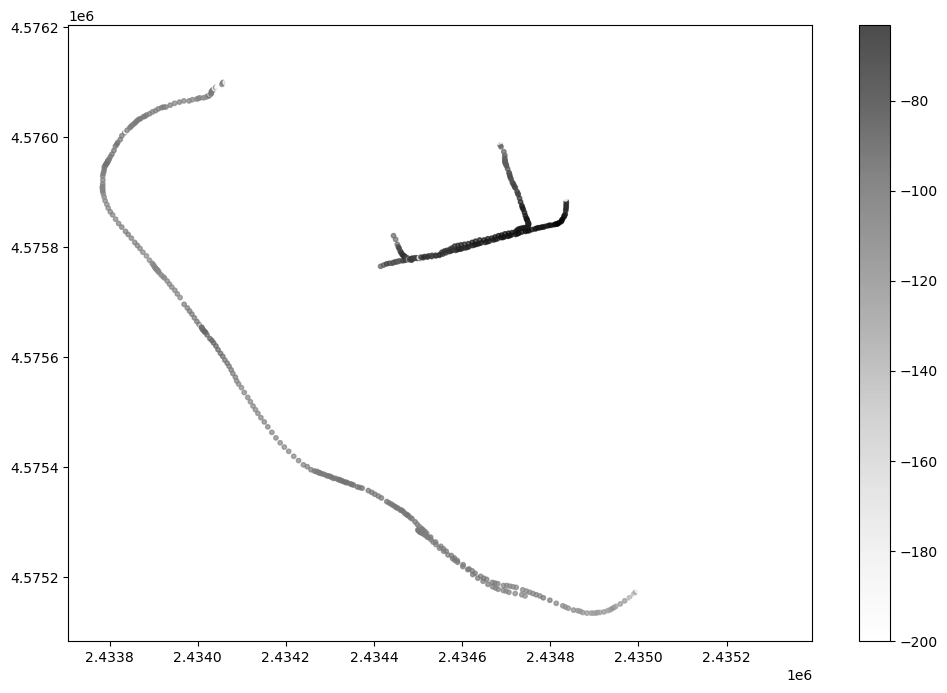

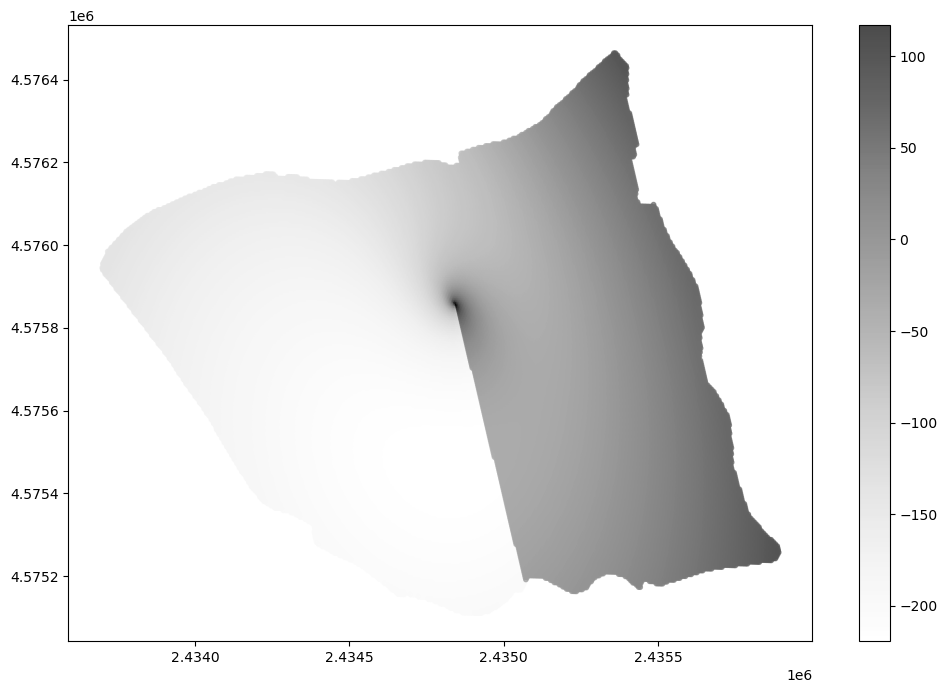

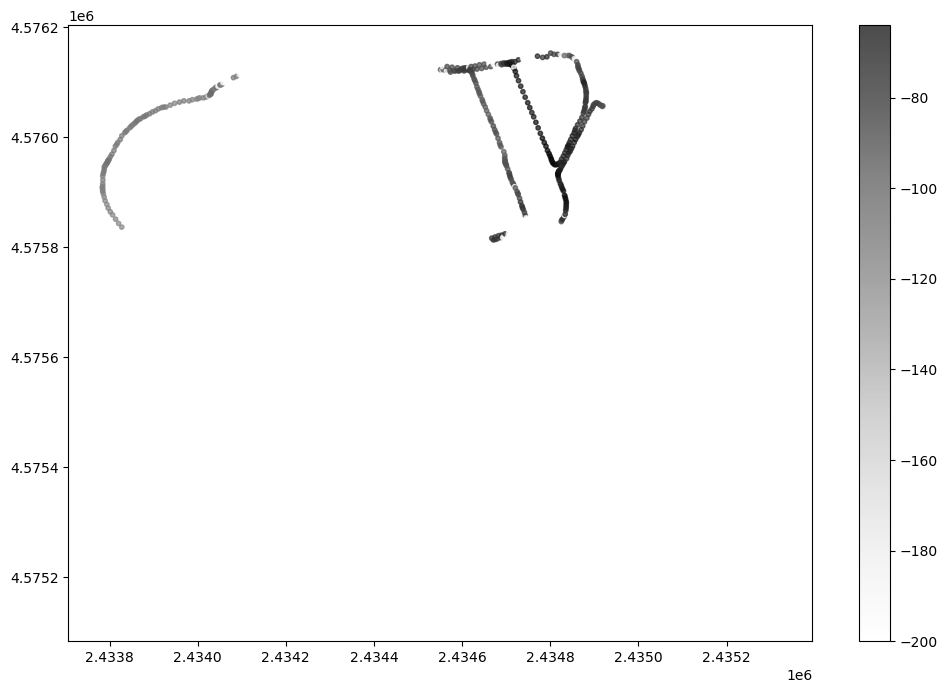

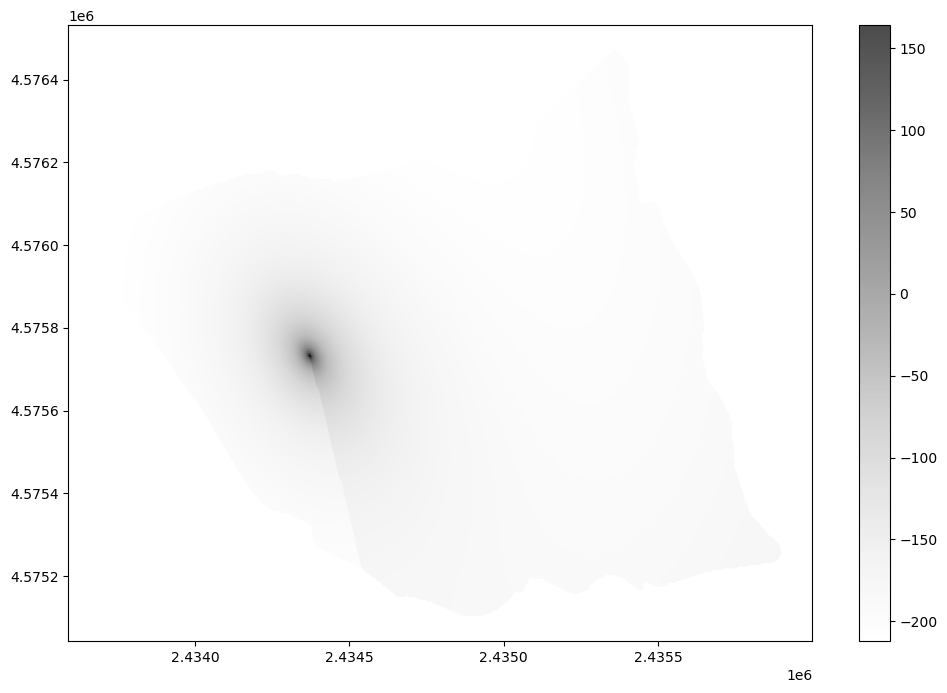

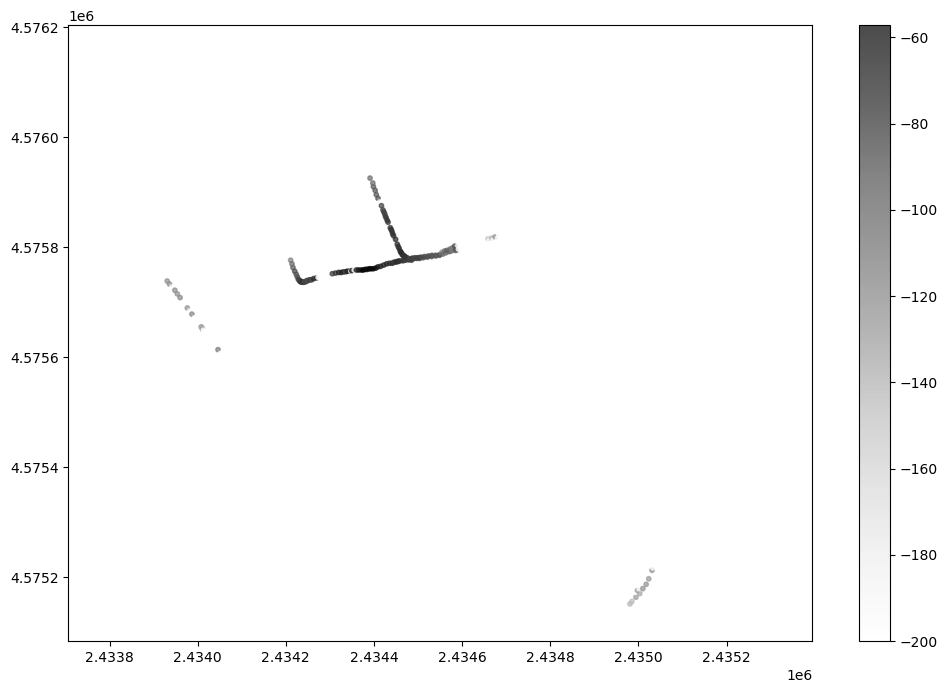

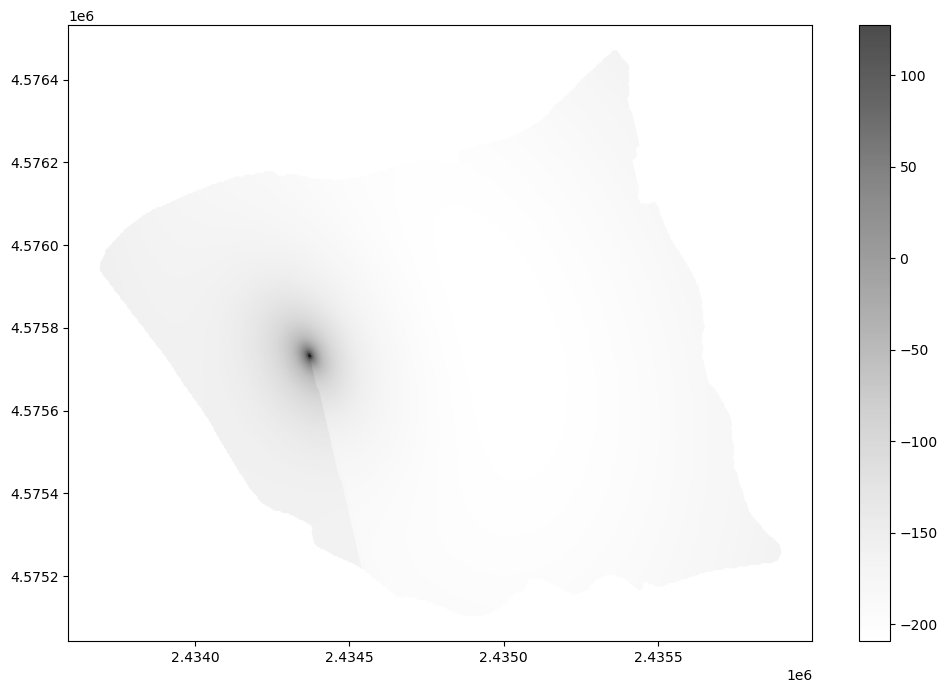

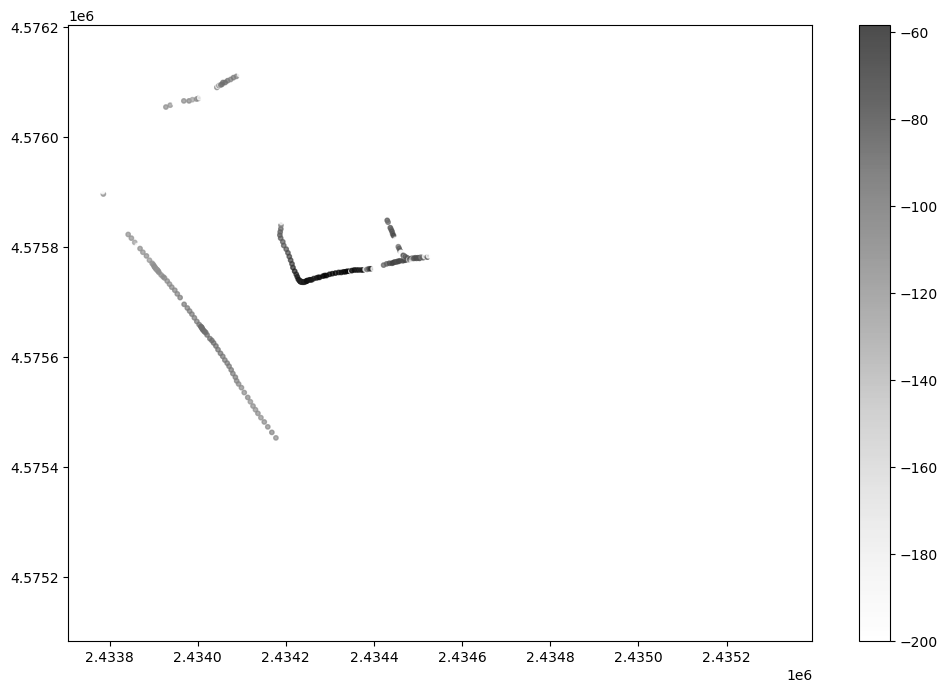

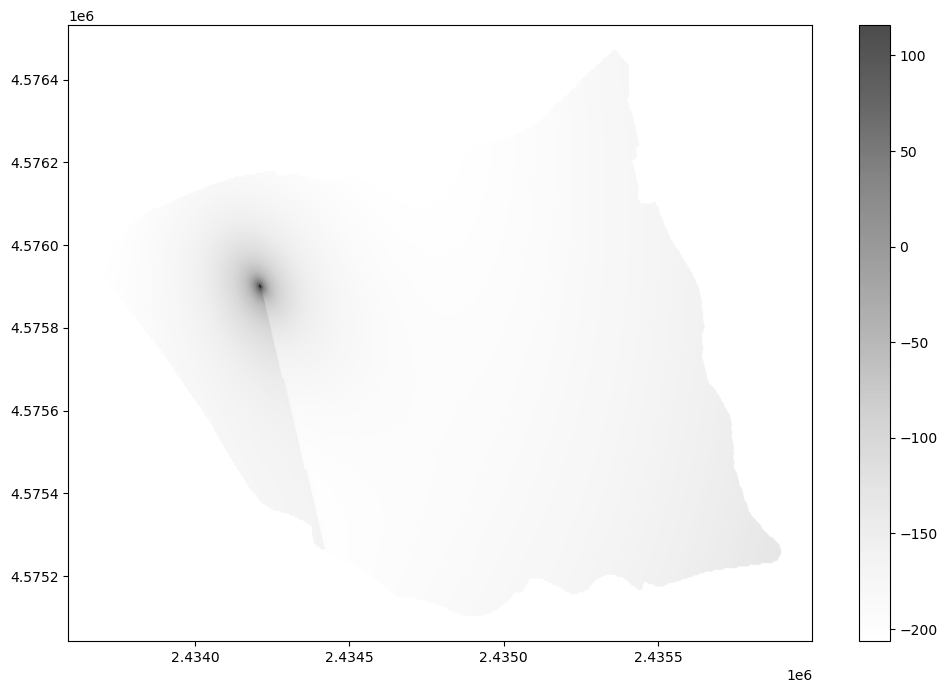

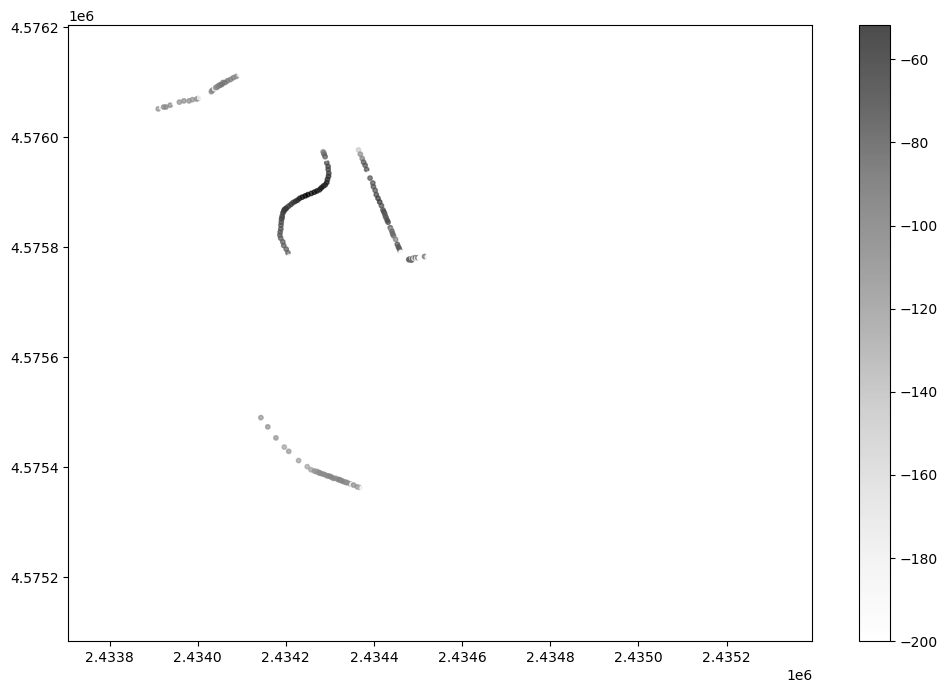

In [13]:
from sklearn.linear_model import LinearRegression

for i in range(9):
    X_train = features[i]
    X_test = pred_features[i]
    y_train = signal_data.iloc[:,i]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    sc = ax.scatter(
        pd.DataFrame(X_test)[1],
        pd.DataFrame(X_test)[0],
        c=y_pred,
        cmap="Greys",
        s=10,
        alpha=0.7
    )

    cbar = plt.colorbar(sc)

    plt.show()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    sc = ax.scatter(
    pd.DataFrame(X_train)[1],
    pd.DataFrame(X_train)[0],
    c=y_train,
    cmap="Greys",
    s=10,
    alpha=0.7
    )

    cbar = plt.colorbar(sc)


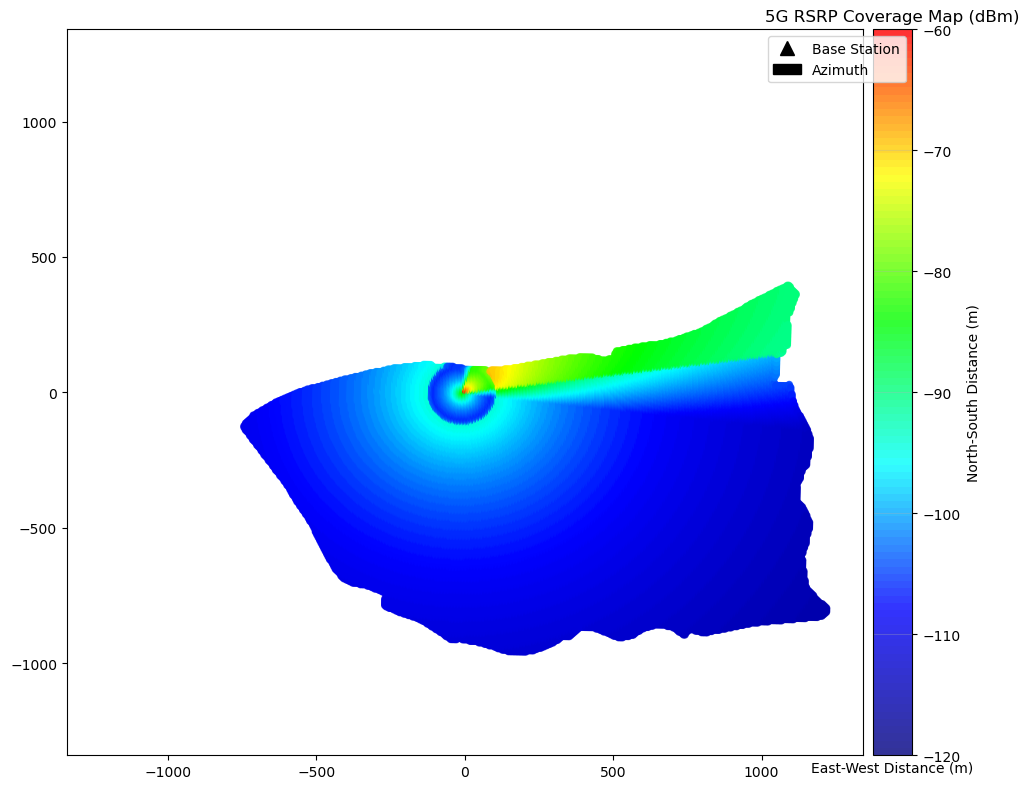

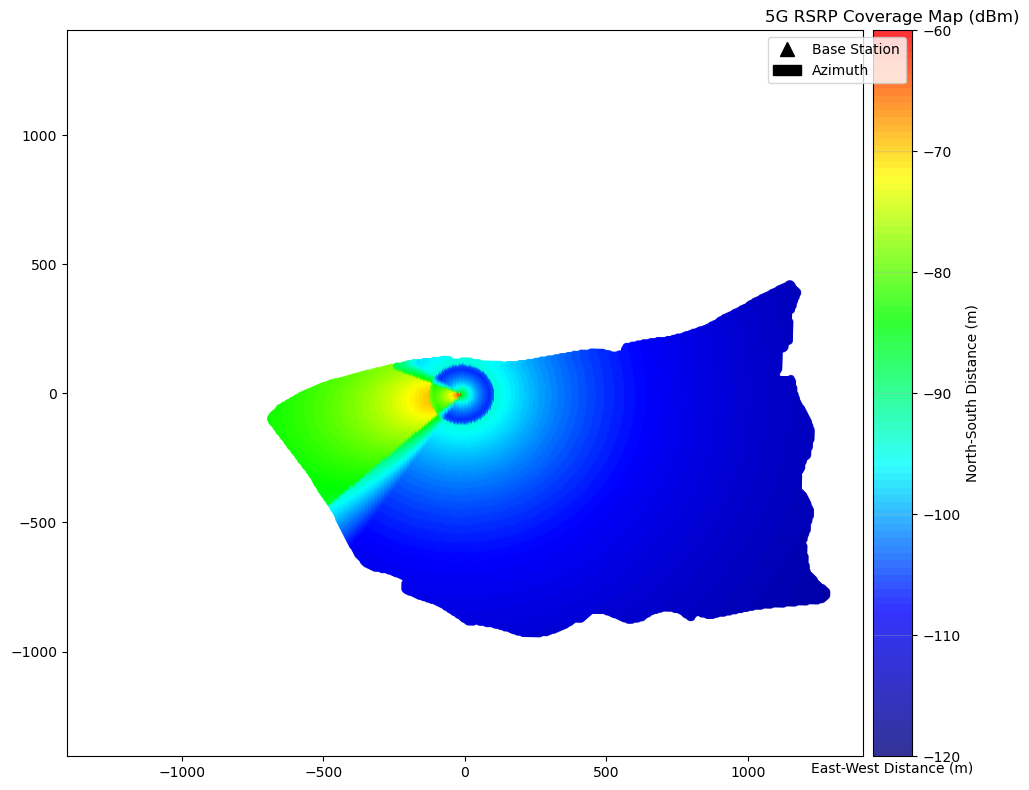

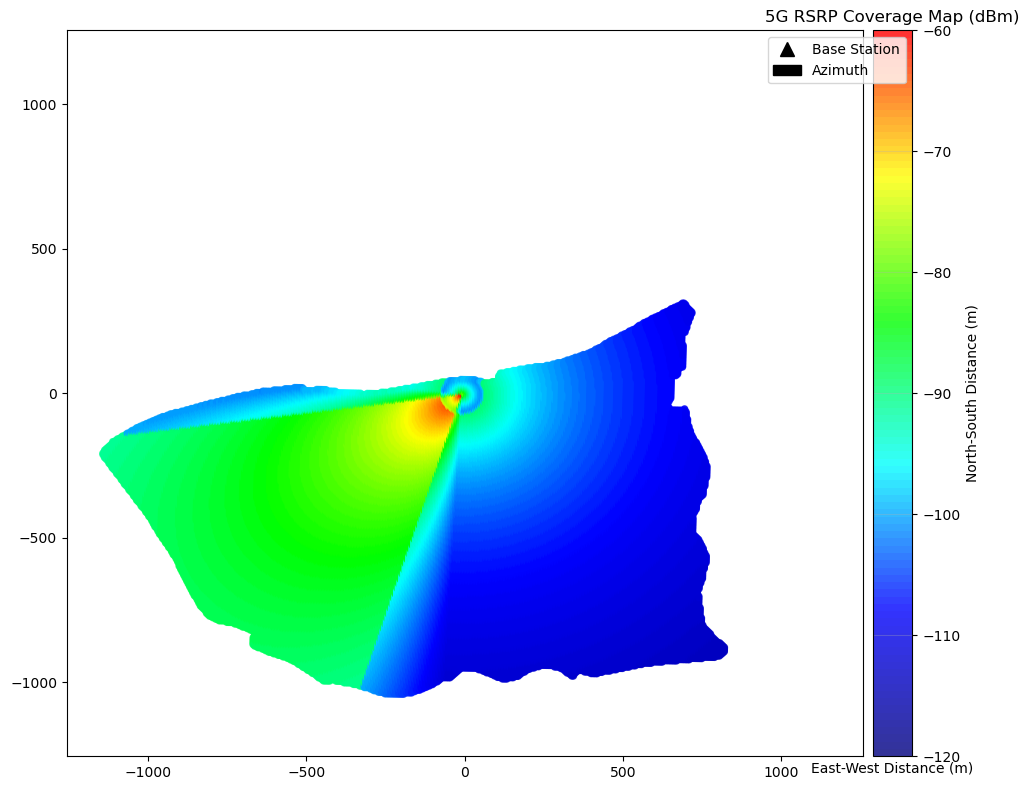

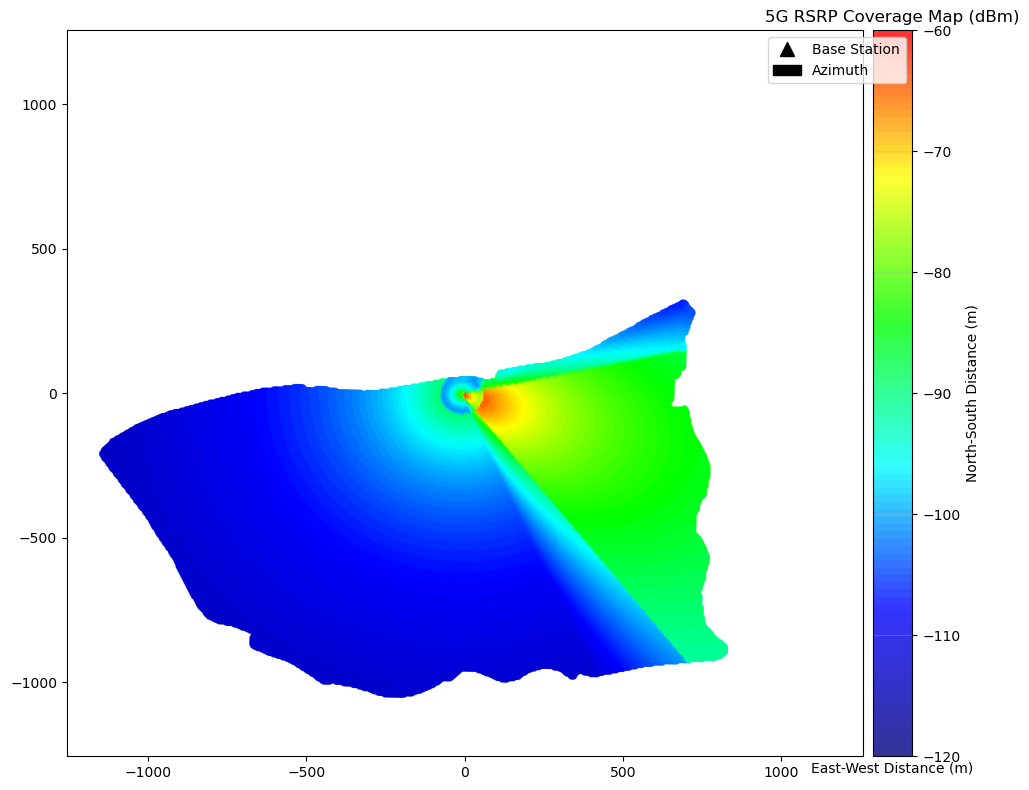

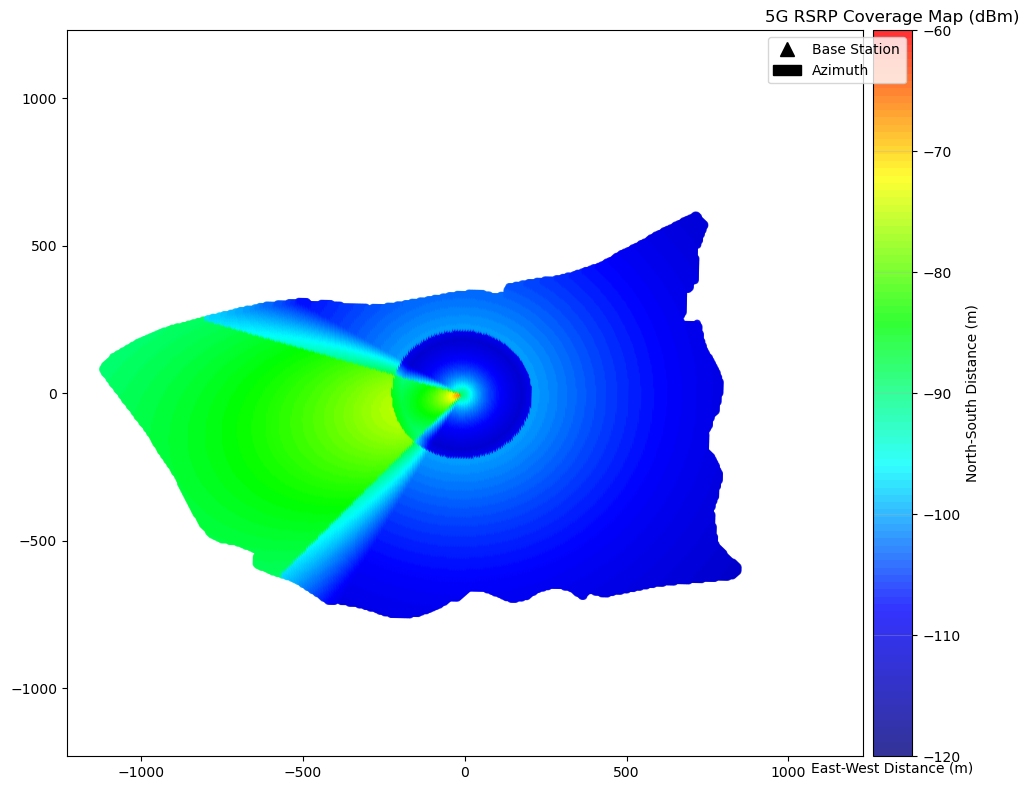

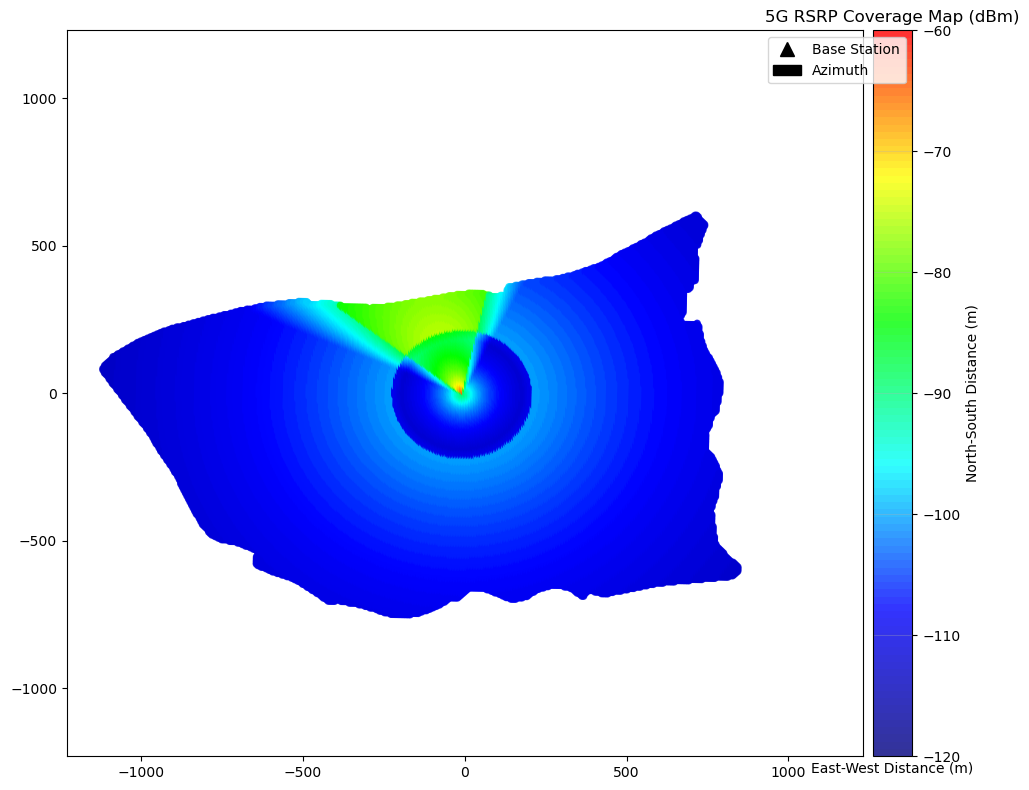

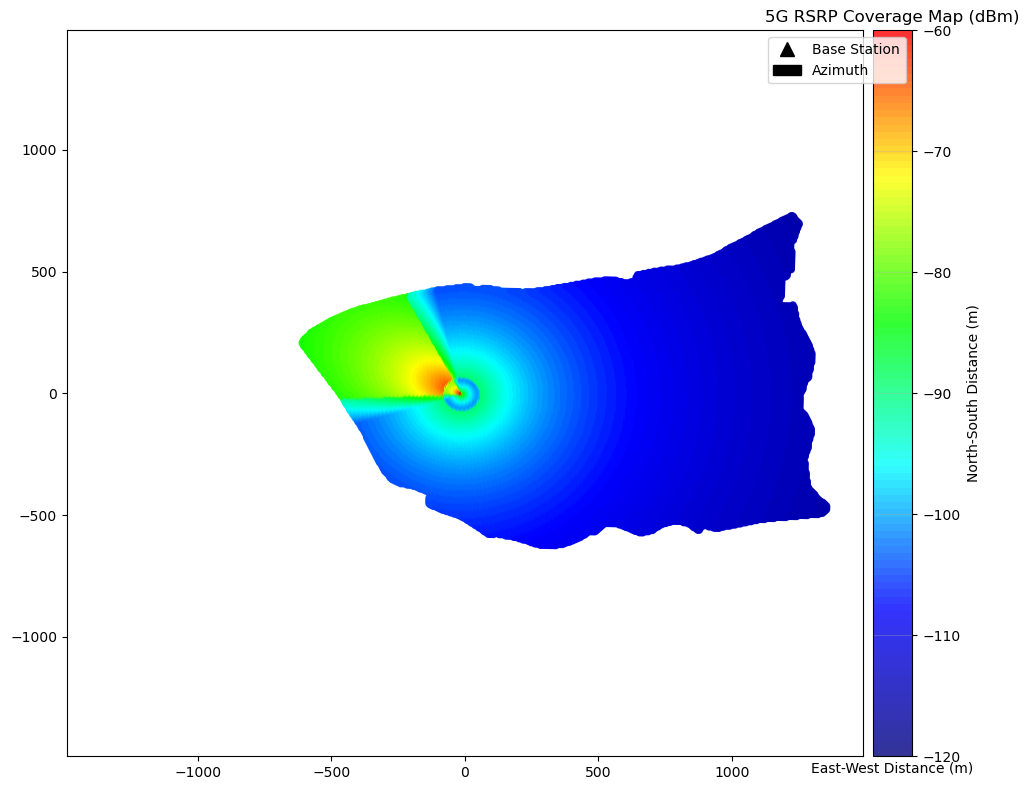

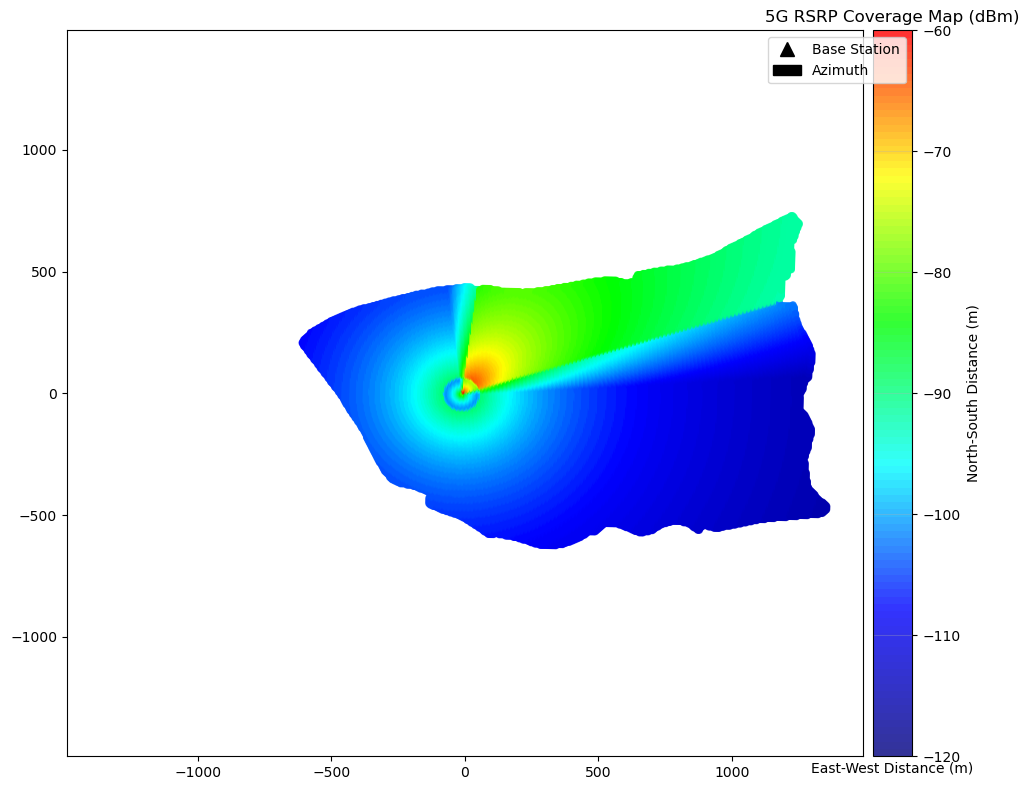

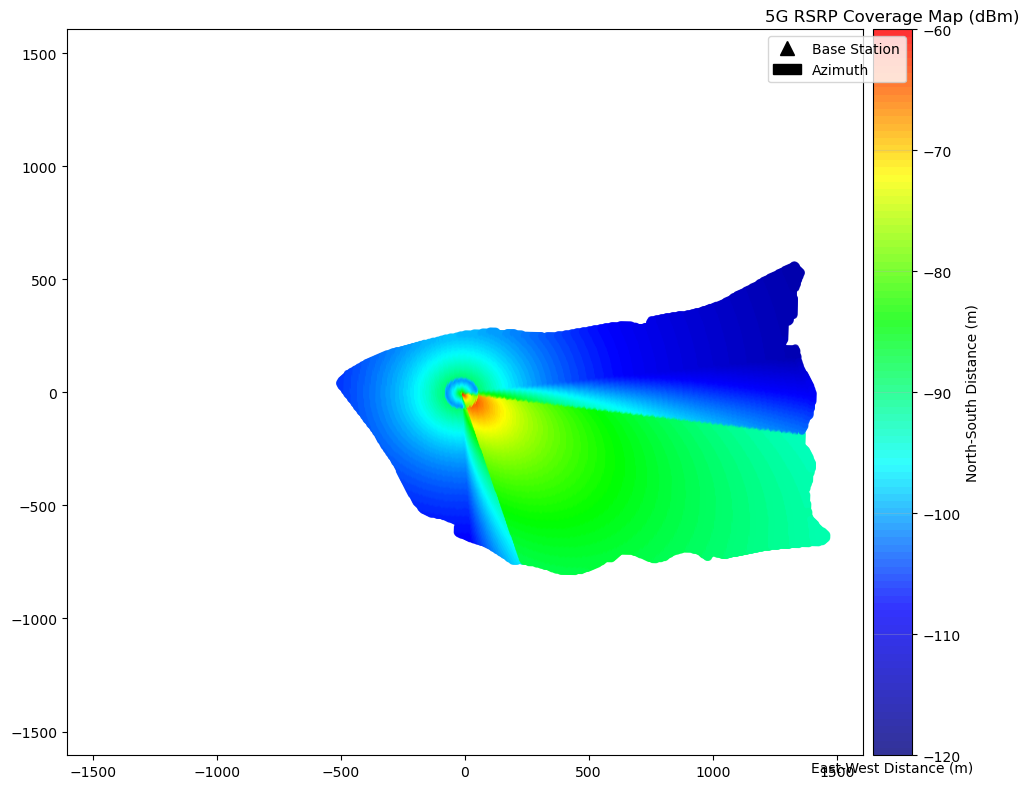

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

def lat_lon_to_xy(lat, lon, base_lat, base_lon):
    """
    Convert latitude and longitude to Cartesian coordinates (x, y) in meters
    where base station is at (0, 0)
    """
    # Constants for conversion (approximate for small distances)
    lat_to_m = 111320  # meters per degree latitude
    lon_to_m = 111320 * np.cos(np.radians(base_lat))  # meters per degree longitude

    # Calculate distances
    x = (lon - base_lon) * lon_to_m
    y = (lat - base_lat) * lat_to_m
    
    return x, y

def xy_to_distance_angle(x, y, height):
    """
    Convert Cartesian coordinates to distance and angles from base station
    Returns: distance (m), horizontal angle (deg), vertical angle (deg)
    """
    # Distance in horizontal plane
    horizontal_distance = np.sqrt(x**2 + y**2)
    
    # Total 3D distance
    distance = np.sqrt(horizontal_distance**2 + height**2)
    
    # Horizontal angle (azimuth) - 0 degrees is North, positive clockwise
    horizontal_angle = np.degrees(np.arctan2(x, y))
    
    # Vertical angle (elevation) - 0 degrees is horizontal, positive upward
    vertical_angle = np.degrees(np.arctan2(height, horizontal_distance))
    
    return distance, horizontal_angle, vertical_angle

def calculate_antenna_gain(horizontal_angle, vertical_angle, azimuth, h_beamwidth, v_beamwidth, 
                          front_to_back_ratio, side_lobe_suppression):
    """
    Calculate antenna gain in dB based on horizontal and vertical angles
    """
    # Normalize angles relative to boresight direction
    h_angle_diff = np.abs((horizontal_angle - azimuth + 180) % 360 - 180)
    v_angle_diff = np.abs(vertical_angle)
    
    # Horizontal pattern - simplified model
    if h_angle_diff <= h_beamwidth/2:
        # Within main beam
        h_gain = -3.0 * (h_angle_diff / (h_beamwidth/2))**2
    elif h_angle_diff <= 180:
        # Side lobes
        h_gain = -min(12.0 * (h_angle_diff / (h_beamwidth/2))**2, front_to_back_ratio)
    else:
        # Back lobe
        h_gain = -front_to_back_ratio
        
    # Vertical pattern - simplified model
    if v_angle_diff <= v_beamwidth/2:
        # Within main beam
        v_gain = -3.0 * (v_angle_diff / (v_beamwidth/2))**2
    else:
        # Outside main beam
        v_gain = -min(12.0 * (v_angle_diff / (v_beamwidth/2))**2, side_lobe_suppression)
    
    # Combine horizontal and vertical gains
    total_gain = h_gain + v_gain
    
    return total_gain

def calculate_path_loss(distance, frequency=3.5e9):
    """
    Calculate path loss using the 3GPP Urban Macro model
    frequency in Hz, distance in meters
    Returns path loss in dB
    """
    # 3GPP Urban Macro model for 5G
    # PL = 28.0 + 22*log10(d) + 20*log10(fc)
    # where d is distance in meters and fc is frequency in GHz
    
    freq_ghz = frequency / 1e9
    
    # Avoid log of zero
    d = max(distance, 1)
    
    path_loss = 28.0 + 22 * np.log10(d) + 20 * np.log10(freq_ghz)
    
    return path_loss

def calculate_rsrp(tx_power_w, ssb_power_dbm, antenna_gain, path_loss):
    """
    Calculate RSRP in dBm
    tx_power_w: Total transmission power in Watts
    ssb_power_dbm: Power per SSB in dBm
    antenna_gain: Antenna gain in dB for the specific direction
    path_loss: Path loss in dB
    """
    # Convert total power to dBm
    tx_power_dbm = 10 * np.log10(tx_power_w) + 30
    
    # RSRP calculation
    rsrp = ssb_power_dbm + antenna_gain - path_loss
    
    return rsrp

def create_rsrp_grid(base_lat, base_lon, azimuth, h_beamwidth, v_beamwidth, height, tx_power,
                    ssb_power_dbm, front_to_back_ratio, side_lobe_suppression, 
                    grid_size=2000, resolution=10, custom_grid=None):
    """
    Create a grid of RSRP values
    
    Parameters:
    -----------
    custom_grid : pandas.DataFrame or None
        If provided, should contain 'Latitude' and 'Longitude' columns.
        If None, a uniform grid will be created.
    grid_size : float
        Size of the grid in meters (only used if custom_grid is None)
    resolution : float
        Resolution in meters (only used if custom_grid is None)
    """
    if custom_grid is None:
        # Create uniform grid coordinates (original behavior)
        grid_points = np.arange(-grid_size/2, grid_size/2, resolution)
        X, Y = np.meshgrid(grid_points, grid_points)
        grid_shape = X.shape
        
        # Initialize RSRP grid
        rsrp_grid = np.zeros_like(X)
        
        # Calculate RSRP for each grid point
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                x, y = X[i, j], Y[i, j]
                
                # Calculate distance and angles
                distance, h_angle, v_angle = xy_to_distance_angle(x, y, height)
                
                # Calculate antenna gain
                gain = calculate_antenna_gain(h_angle, v_angle, azimuth, h_beamwidth, v_beamwidth,
                                            front_to_back_ratio, side_lobe_suppression)
                
                # Calculate path loss
                p_loss = calculate_path_loss(distance)
                
                # Calculate RSRP
                rsrp = calculate_rsrp(tx_power, ssb_power_dbm, gain, p_loss)
                
                # Store in grid
                rsrp_grid[i, j] = rsrp
                
        return grid_points, rsrp_grid
    
    else:
        
        lats = custom_grid['Latitude'].values
        lons = custom_grid['Longitude'].values
        
        # Initialize RSRP list
        rsrp_values = np.zeros(len(lats))
        
        # Calculate x, y coordinates for each point
        x_values = []
        y_values = []
        
        # Process each grid point
        for i, (lat, lon) in enumerate(zip(lats, lons)):
            # Convert lat/lon to x/y
            x, y = lat_lon_to_xy(lat, lon, base_lat, base_lon)
            x_values.append(x)
            y_values.append(y)
            
            # Calculate distance and angles
            distance, h_angle, v_angle = xy_to_distance_angle(x, y, height)
            
            # Calculate antenna gain
            gain = calculate_antenna_gain(h_angle, v_angle, azimuth, h_beamwidth, v_beamwidth,
                                        front_to_back_ratio, side_lobe_suppression)
            
            # Calculate path loss
            p_loss = calculate_path_loss(distance)
            
            # Calculate RSRP
            rsrp = calculate_rsrp(tx_power, ssb_power_dbm, gain, p_loss)
            
            # Store RSRP value
            rsrp_values[i] = rsrp
        
        # Return the data in a format that includes coordinates
        return (lats, lons, x_values, y_values, rsrp_values)

def plot_rsrp_grid(grid_data, base_lat, base_lon, azimuth, is_custom_grid=False):
    """
    Plot the RSRP grid with color map
    
    Parameters:
    -----------
    grid_data : tuple
        Either (grid_points, rsrp_grid) for uniform grid or
        (lats, lons, x_values, y_values, rsrp_values) for custom grid
    is_custom_grid : bool
        Whether the provided data is from a custom grid
    """
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Define custom colormap (similar to what's used in professional tools)
    colors = [(0, 0, 0.5), (0, 0, 1), (0, 1, 1), (0, 1, 0), (1, 1, 0), (1, 0, 0)]
    cmap = LinearSegmentedColormap.from_list('rsrp_cmap', colors, N=100)
    
    if not is_custom_grid:
        # For uniform grid (original behavior)
        grid_points, rsrp_grid = grid_data
        
        # Plot RSRP grid
        im = plt.imshow(rsrp_grid, extent=[grid_points[0], grid_points[-1], grid_points[0], grid_points[-1]],
                      origin='lower', cmap=cmap, vmin=-120, vmax=-60)
    else:
        # For custom grid points
        lats, lons, x_values, y_values, rsrp_values = grid_data
        
        # Plot RSRP as scatter points
        im = plt.scatter(x_values, y_values, c=rsrp_values, cmap=cmap, 
                       vmin=-120, vmax=-60, s=20, alpha=0.8)
        
        # Set reasonable axis limits
        max_dist = max(max(abs(min(x_values)), abs(max(x_values))), 
                     max(abs(min(y_values)), abs(max(y_values))))
        plt.xlim(-max_dist*1.1, max_dist*1.1)
        plt.ylim(-max_dist*1.1, max_dist*1.1)
    
    # Add colorbar
    divider = make_axes_locatable(plt.gca())
    cax = divider.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im, cax=cax, label='RSRP (dBm)')
    
    # Add base station marker and azimuth line
    plt.plot(0, 0, 'k^', markersize=10, label='Base Station')
    
    # Draw azimuth line
    azimuth_rad = np.radians(90 - azimuth)  # Convert from compass to math angles
    line_length = 500 if not is_custom_grid else max_dist * 0.5
    end_x = line_length * np.cos(azimuth_rad)
    end_y = line_length * np.sin(azimuth_rad)
    plt.arrow(0, 0, end_x, end_y, head_width=line_length*0.1, head_length=line_length*0.1, 
             fc='k', ec='k', label='Azimuth')
    
    # Add grid and labels
    plt.grid(True, alpha=0.3)
    plt.xlabel('East-West Distance (m)')
    plt.ylabel('North-South Distance (m)')
    plt.title('5G RSRP Coverage Map (dBm)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":

    for idx,row in kabinets.iterrows():   
        base_lat = row["Latitude"] 
        base_lon = row["Longitude"]
        azimuth = row["Azimuth"] 
        h_beamwidth = row["Horizontal_Beamwidth"] 
        v_beamwidth = row["Vertical_Beamwidth"] 
        height = row["Height"]

        grid_data_ = create_rsrp_grid(
            base_lat, base_lon, azimuth, h_beamwidth, v_beamwidth, height, tx_power=200,
            ssb_power_dbm=17.91, front_to_back_ratio=25, side_lobe_suppression=16,
            custom_grid=grid_data)
            

        plot_rsrp_grid(grid_data_, base_lat, base_lon, azimuth, is_custom_grid=True)